In [1]:
import re , pandas as pd , numpy as np , matplotlib.pyplot as plt , seaborn as sns
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
from wordcloud import WordCloud
nltk.download('stopwords')
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bedos\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
data = pd.read_csv('enron_spam_data.csv')
data.head()

,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


In [3]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33107 entries, 1 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Message ID  33107 non-null  int64 
 1   Subject     33107 non-null  object
 2   Message     33107 non-null  object
 3   Spam/Ham    33107 non-null  object
 4   Date        33107 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.5+ MB


In [5]:
data['label'] = data['Spam/Ham'].map({'ham':0 , 'spam':1})

data['label'].value_counts()

label
1    16614
0    16493
Name: count, dtype: int64

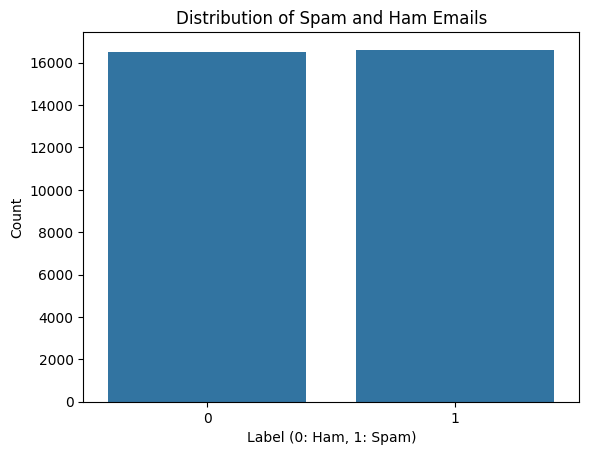

In [6]:
# Data Visualization
sns.countplot(x='label' , data=data)
plt.title('Distribution of Spam and Ham Emails')
plt.xlabel('Label (0: Ham, 1: Spam)')
plt.ylabel('Count')
plt.show()

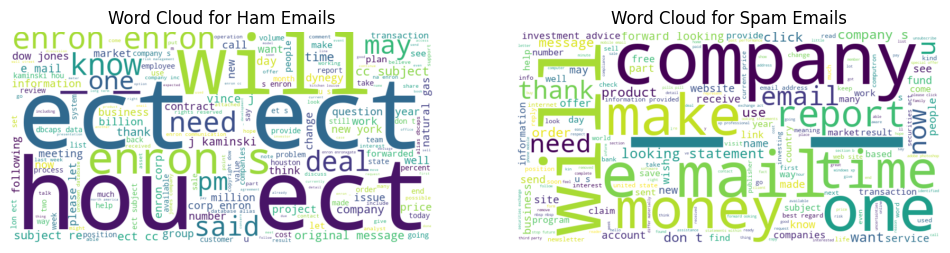

In [7]:
ham_text = ' '.join(data[data['label'] == 0]['Message'])
spam_text = ' '.join(data[data['label'] == 1]['Message'])
ham_wordcloud = WordCloud(width=800 , height=400 , background_color='white').generate(ham_text)
spam_wordcloud = WordCloud(width=800 , height=400 , background_color='white').generate(spam_text)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(ham_wordcloud , interpolation='bilinear')
plt.title('Word Cloud for Ham Emails')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(spam_wordcloud , interpolation='bilinear')
plt.title('Word Cloud for Spam Emails')
plt.axis('off')
plt.show()

In [10]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]' , '' , text)
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

data['cleaned_message'] = data['Message'].apply(preprocess_text)
data.head()

,Message ID,Subject,Message,Spam/Ham,Date,label,cleaned_message
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,0,gary production high island larger block 1 2 c...
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,0,calpine daily gas nomination 1 doc
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,0,fyi see note already done stella forwarded ste...
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,fyi forwarded lauri allen hou ect 12 14 99 12 ...
5,5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14,0,jackie since inlet 3 river plant shut 10 19 99...


In [11]:
model_data = data[['cleaned_message' , 'label']]
X = model_data['cleaned_message']
y = model_data['label']
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [12]:
multinomial_nb = MultinomialNB()
multinomial_nb.fit(X_train_vec , y_train)
y_pred_nb = multinomial_nb.predict(X_test_vec)
print("Multinomial Naive Bayes Classification Report:")
print(classification_report(y_test , y_pred_nb))
print("Multinomial Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test , y_pred_nb))
print("Multinomial Naive Bayes Accuracy:", accuracy_score(y_test , y_pred_nb))


Multinomial Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3307
           1       0.99      0.99      0.99      3315

    accuracy                           0.99      6622
   macro avg       0.99      0.99      0.99      6622
weighted avg       0.99      0.99      0.99      6622

Multinomial Naive Bayes Confusion Matrix:
[[3264   43]
 [  43 3272]]
Multinomial Naive Bayes Accuracy: 0.987012987012987


In [13]:
log_reg = LogisticRegression()
log_reg.fit(X_train_vec , y_train)
y_pred_log = log_reg.predict(X_test_vec)
print("Logistic Regression Classification Report:")
print(classification_report(y_test , y_pred_log))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test , y_pred_log))
print("Logistic Regression Accuracy:", accuracy_score(y_test , y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3307
           1       0.98      0.99      0.99      3315

    accuracy                           0.99      6622
   macro avg       0.99      0.99      0.99      6622
weighted avg       0.99      0.99      0.99      6622

Logistic Regression Confusion Matrix:
[[3243   64]
 [  20 3295]]
Logistic Regression Accuracy: 0.9873150105708245
